# 03 - SKU OCR

Stage 3 of 3: given the padded crop, de-rotated upright with the
*ground-truth* angle (not stage 2's prediction - keeps this stage's own
accuracy measurable independent of stage 2's), read the SKU text.

The crop's bbox is position/scale-jittered like stage 2's input
(`geometry.jitter_bbox`, via `OcrDataset`'s default `jitter=True`) so this
stage isn't fragile to stage 1's real imprecision either. It is *not*
angle-jittered, though - unlike `OrientationNet` (translation-invariant via
global average pooling), the CRNN below reads left-to-right through vertical
column slices, so even a modest rotation jitter broke training completely
(loss never moved off its initial plateau). Reading tilted text is a
fundamentally harder task for this architecture than reading upright text
from a slightly-off-center crop, so the pipeline leans on stage 2 to actually
straighten the crop rather than asking stage 3 to tolerate not-quite-straight
input.

A small CRNN (conv backbone -> sequence over the width axis -> BiLSTM ->
per-timestep character logits), trained with CTC loss so it doesn't need
per-character bounding boxes - just the string.

Training vocabulary is ~800 synthetic `SKU-####` strings sampled from the
*same* numeric range (1000-9999) the real catalog lives in, excluding only
the 20 exact catalog numbers - an earlier version sampled from 2000-9999
only, which seemed like a safer way to avoid overlap but actually meant the
model never saw a training example with a leading "1" digit and
misread every real catalog SKU as a result (0% catalog accuracy despite 84%
on the synthetic split it was tested against). Held-out-ness only requires
excluding the exact catalog *numbers*, not their whole numeric neighborhood.

Note on training dynamics: like stage 2, this model's loss can sit flat for
15-20 epochs before breaking through - the jittered input distribution is
harder to fit than pixel-perfect ground truth, so give it enough epochs.

In [1]:
import sys
from pathlib import Path


def _find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "requirements.txt").is_file():
            return candidate
    raise RuntimeError("Could not locate the vision-ml project root from " + str(start))


PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT


PosixPath('/Users/lroland/Projects/github.com/distribution-center/vision-ml')

In [2]:
import contextlib
import json
import random

import matplotlib.pyplot as plt
import mlflow
import torch
from PIL import Image
from torch.utils.data import DataLoader

from src import datasets, geometry, models, settings, tracking

random.seed(0)
torch.manual_seed(0)

# nn.CTCLoss has no MPS kernel as of this torch version (NotImplementedError on Apple Silicon) -
# this stage trains on CPU regardless of what's available; the model is small enough that it's
# still fast.
DEVICE = "cpu"
DEVICE


'cpu'

## Load data

In [3]:
records = datasets.load_manifest(settings.RAW_DIR / "manifest.jsonl")
splits = json.loads((settings.RAW_DIR / "splits.json").read_text())


def _records_for(skus):
    sku_set = set(skus)
    return [r for r in records if r["sku"] in sku_set]


train_records = _records_for(splits["train_skus"])
val_records = _records_for(splits["val_skus"])
catalog_records = _records_for(splits["catalog_skus"])
print(f"train: {len(train_records)} images, {len(splits['train_skus'])} SKUs")
print(f"val:   {len(val_records)} images, {len(splits['val_skus'])} SKUs")
print(f"catalog (held out, real product SKUs): {len(catalog_records)} images, {len(splits['catalog_skus'])} SKUs")

BATCH_SIZE = 32
PAD_FRAC = 0.2
def _make_ocr_dataset(records):
    # Position/scale jitter (see geometry.jitter_bbox), but *not* angle jitter: unlike
    # OrientationNet (translation-invariant via global average pooling), the CRNN reads
    # left-to-right through vertical column slices, so even a modest rotation jitter (tried
    # angle_jitter_std=8, matching OrientationNet's real error) broke training completely -
    # loss never moved off its initial plateau in 25 epochs. Reading tilted text is a
    # fundamentally different, harder task for this architecture than reading upright text
    # from a slightly-off-center crop. Leaning on stage 2 to actually straighten the crop
    # (rather than making stage 3 tolerate not-quite-straight input) is the more tractable split.
    return datasets.OcrDataset(records, settings.RAW_DIR, pad_frac=PAD_FRAC, angle_jitter_std=0.0)


train_ds = _make_ocr_dataset(train_records)
val_ds = _make_ocr_dataset(val_records)
catalog_ds = _make_ocr_dataset(catalog_records)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=datasets.ocr_collate)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=datasets.ocr_collate)
catalog_loader = DataLoader(catalog_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=datasets.ocr_collate)


train: 5440 images, 680 SKUs
val:   640 images, 80 SKUs
catalog (held out, real product SKUs): 800 images, 20 SKUs


## Metrics: character error rate + exact-match accuracy

In [4]:
def _levenshtein(a: str, b: str) -> int:
    if len(a) < len(b):
        a, b = b, a
    previous = list(range(len(b) + 1))
    for i, ca in enumerate(a, start=1):
        current = [i] + [0] * len(b)
        for j, cb in enumerate(b, start=1):
            cost = 0 if ca == cb else 1
            current[j] = min(previous[j] + 1, current[j - 1] + 1, previous[j - 1] + cost)
        previous = current
    return previous[-1]


@torch.no_grad()
def evaluate(model, loader) -> dict:
    model.eval()
    total_chars = 0
    total_edits = 0
    exact_matches = 0
    total = 0
    for images, _targets, _lengths, skus in loader:
        images = images.to(DEVICE)
        log_probs = model(images)
        preds = models.greedy_ctc_decode(log_probs)
        for pred, truth in zip(preds, skus):
            total_edits += _levenshtein(pred, truth)
            total_chars += len(truth)
            exact_matches += int(pred == truth)
            total += 1
    return {
        "cer": total_edits / max(total_chars, 1),
        "exact_match_accuracy": exact_matches / max(total, 1),
    }


## Train

In [5]:
EPOCHS = 40
LR = 1e-3

model = models.CRNNReader().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
ctc_loss = torch.nn.CTCLoss(blank=models.BLANK_IDX, zero_infinity=True)

tracking.configure_tracking("ocr")
run_ctx = mlflow.start_run(run_name="ocr") if tracking.is_enabled() else contextlib.nullcontext()

history = {"train_loss": [], "val_cer": [], "val_exact_match": []}
best_val_exact_match = -1.0
best_state_dict = None

with run_ctx:
    if tracking.is_enabled():
        mlflow.log_params({"epochs": EPOCHS, "batch_size": BATCH_SIZE, "lr": LR, "pad_frac": PAD_FRAC, "model": "CRNNReader"})

    for epoch in range(EPOCHS):
        model.train()
        train_loss_total = 0.0
        n_images = 0
        for images, targets, target_lengths, _skus in train_loader:
            images, targets, target_lengths = images.to(DEVICE), targets.to(DEVICE), target_lengths.to(DEVICE)
            optimizer.zero_grad()
            log_probs = model(images)  # (T, B, C)
            input_lengths = torch.full((images.size(0),), log_probs.size(0), dtype=torch.long, device=DEVICE)
            loss = ctc_loss(log_probs, targets, input_lengths, target_lengths)
            loss.backward()
            optimizer.step()
            train_loss_total += loss.item() * images.size(0)
            n_images += images.size(0)
        train_loss = train_loss_total / n_images

        val_metrics = evaluate(model, val_loader)
        history["train_loss"].append(train_loss)
        history["val_cer"].append(val_metrics["cer"])
        history["val_exact_match"].append(val_metrics["exact_match_accuracy"])
        is_best = val_metrics["exact_match_accuracy"] > best_val_exact_match
        if is_best:
            best_val_exact_match = val_metrics["exact_match_accuracy"]
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"epoch {epoch + 1:2d}/{EPOCHS}  train_loss={train_loss:.4f}  "
              f"val_cer={val_metrics['cer']:.3f}  val_exact_match={val_metrics['exact_match_accuracy']:.3f}"
              f"{'  (best)' if is_best else ''}")

        if tracking.is_enabled():
            mlflow.log_metrics({"train_loss": train_loss, **{f"val_{k}": v for k, v in val_metrics.items()}}, step=epoch)

    # Save the best-val-exact-match epoch's weights, not just the last epoch - see the same
    # reasoning in 01_sticker_localization.ipynb.
    model.load_state_dict(best_state_dict)
    settings.MODELS_DIR.mkdir(parents=True, exist_ok=True)
    checkpoint_path = settings.MODELS_DIR / "ocr.pt"
    torch.save(model.state_dict(), checkpoint_path)
    if tracking.is_enabled():
        mlflow.log_metric("best_val_exact_match_accuracy", best_val_exact_match)
        mlflow.log_artifact(str(checkpoint_path))

print(f"saved {checkpoint_path} (best val_exact_match={best_val_exact_match:.3f})")


epoch  1/40  train_loss=2.3249  val_cer=0.515  val_exact_match=0.000  (best)


epoch  2/40  train_loss=1.3287  val_cer=0.500  val_exact_match=0.000


epoch  3/40  train_loss=1.2881  val_cer=0.441  val_exact_match=0.000


epoch  4/40  train_loss=1.2590  val_cer=0.447  val_exact_match=0.000


epoch  5/40  train_loss=1.2522  val_cer=0.431  val_exact_match=0.000


...

epoch 36/40  train_loss=0.0262  val_cer=0.027  val_exact_match=0.831


epoch 37/40  train_loss=0.0145  val_cer=0.009  val_exact_match=0.945  (best)


epoch 38/40  train_loss=0.0175  val_cer=0.008  val_exact_match=0.947  (best)


epoch 39/40  train_loss=0.0188  val_cer=0.008  val_exact_match=0.939


epoch 40/40  train_loss=0.0156  val_cer=0.048  val_exact_match=0.673
saved /Users/lroland/Projects/github.com/distribution-center/vision-ml/data/models/ocr.pt (best val_exact_match=0.947)


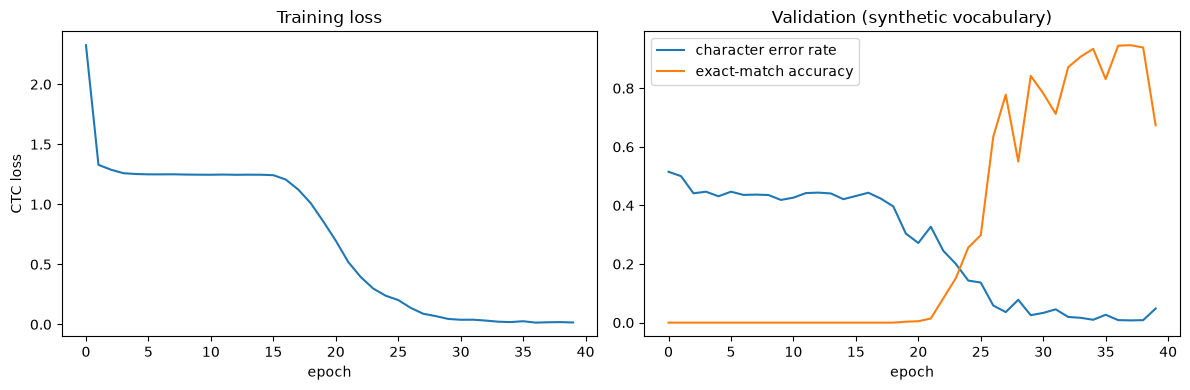

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history["train_loss"])
ax1.set_xlabel("epoch"); ax1.set_ylabel("CTC loss"); ax1.set_title("Training loss")
ax2.plot(history["val_cer"], label="character error rate")
ax2.plot(history["val_exact_match"], label="exact-match accuracy")
ax2.set_xlabel("epoch"); ax2.legend(); ax2.set_title("Validation (synthetic vocabulary)")
plt.tight_layout()
plt.show()


## Held-out metrics: synthetic vocabulary vs. the real catalog

These numbers matter more than the training curve above - the synthetic
validation split shows character-level generalization, but the catalog split
is the number that would actually matter in the demo.

In [7]:
val_metrics = evaluate(model, val_loader)
catalog_metrics = evaluate(model, catalog_loader)
print("synthetic val split :", val_metrics)
print("real catalog (never trained on):", catalog_metrics)


synthetic val split : {'cer': 0.007421875, 'exact_match_accuracy': 0.953125}
real catalog (never trained on): {'cer': 0.011875, 'exact_match_accuracy': 0.91125}


## Qualitative check: predicted vs. actual text

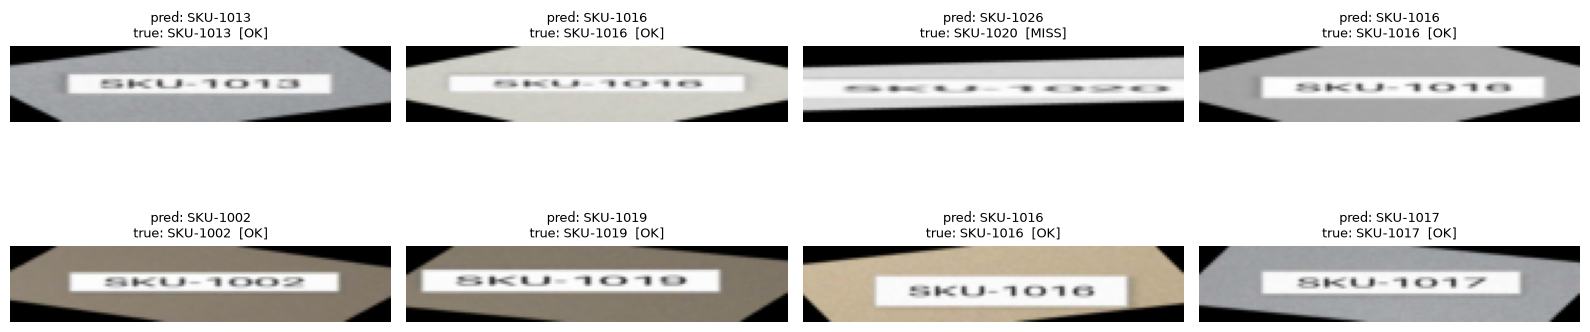

In [8]:
model.eval()
sample = random.sample(catalog_records, 8)

fig, axes = plt.subplots(2, 4, figsize=(16, 5))
with torch.no_grad():
    for ax, record in zip(axes.flat, sample):
        image = Image.open(settings.RAW_DIR / record["image_path"]).convert("RGB")
        canvas_size = image.size
        corners = record["corners_xy"]
        bbox = geometry.corners_to_bbox(corners)
        padded = geometry.pad_bbox(bbox, PAD_FRAC, canvas_size)
        crop = image.crop(padded)
        angle = geometry.corners_to_angle_degrees(corners)
        upright = geometry.rotate_upright(crop, angle).resize((models.CRNNReader.WIDTH, models.CRNNReader.HEIGHT), Image.BILINEAR)

        tensor = datasets.image_to_tensor(upright).unsqueeze(0).to(DEVICE)
        pred = models.greedy_ctc_decode(model(tensor))[0]

        ax.imshow(upright)
        ok = "OK" if pred == record["sku"] else "MISS"
        ax.set_title(f"pred: {pred}\ntrue: {record['sku']}  [{ok}]", fontsize=9)
        ax.axis("off")
plt.tight_layout()
plt.show()
